# Sales Analysis 

This project focuses on the integration and analysis of multiple data sources to evaluate sales performance over a one\-month period\.

The analysis combines data from products, sellers, and transaction records to generate actionable insights and support business decision\-making\.

Key objectives include identifying top\-performing products, evaluating revenue drivers, assessing seller performance, and analyzing sales trends over time\.

In [1]:
# Instalación de nuevas librerías en nuestros proyectos
!pip install openpyxl==3.0.10


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.1/242.1 kB 5.6 MB/s eta 0:00:00
  Attempting uninstall: openpyxl
    Found existing installation: openpyxl 3.1.5
    Not uninstalling openpyxl at /toolkit-cache/2.2.0/python3.11/kernel-libs/lib/python3.11/site-packages, outside environment /root/venv
    Can't uninstall 'openpyxl'. No files were found to uninstall.

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
^C


In [2]:
# imports
import numpy as np
import pandas as pd
import sqlite3 as sql3 
import matplotlib.pyplot as plt
import seaborn as sns


<h2>Paso 1: Alcances del proyecto y obtener datos</h2>
<h3>Alcances del proyecto</h3>
<p>En este proyecto vamos a integrar tres sets de datos con lista de vendedores, lista de artículos y registro de operaciones de un mes, que nos ayudarán a responder a las preguntas: </p>
<ul>
<li>¿Cuál es el artículo más vendido? (unidades)</li>
<li>¿Qué artículo es el que más ingresos nos proporcionó?</li>
<li>¿A qué vendedor debe otorgarse el bono por "Mejor vendedor del mes"?</li>
<li>¿Hay grandes variaciones en ventas a lo largo del mes?</li>
</ul>
<p>Para este proyecto utilizaremos herramientas de Pandas para análisis exploratorio, Numpy para el análisis de ciertas columnas y Matplotlib/Seaborn para visualización de resultados.</p>
</ul>

<h3>Descripción y obtención de los datos</h3>
<h4>Fuentes de datos</h4>
<ul>
<li>articles.db: BD con datos de los artículos.</li>
<li>sellers.xlsx: datos de los vendedores.</li>
<li>orders.csv: registro de las ventas de un mes.</li>
</ul>

In [3]:
# Levanto los datos en 3 diferentes dataframes

#ARTÍCULOS
conn = sql3.connect('/work/data/articles.db')
sql_query = pd.read_sql_query('SELECT * FROM articles', conn)
df_articles = pd.DataFrame(sql_query, columns= ['article_id', 'article_name', 'unit_price'])

print(df_articles)

    article_id      article_name unit_price
0        20015        Smartphone     525.00
1        20016           Full Pc    2127.81
2        20017           Monitor     230.00
3        20018            Tablet     130.00
4        20019              Desk     130.10
5        20020             Chair     335.64
6        20021             Modem      67.50
7        20022    Range Extender      20.45
8        20023          Notebook    1000.00
9        20024           Netbook     145.00
10       20025               HDD      54.62
11       20026               SDD      22.00
12       20027        Ram Memory      35.95
13       20028       Motherboard     138.38
14       20029             Mouse      30.30
15       20030        Fan Cooler       4.25
16       20031            Webcam      20.07
17       20032          Keyboard      22.60
18       20033        Headphones      23.30
19       20034           Scanner     185.00
20       20035              Case      37.90
21       20036        Video Card

In [4]:
#VENDEDORES

df_sellers = pd.read_excel('/work/data/sellers.xlsx', index_col=0)
print(df_sellers)


                 seller_name
seller_id                   
1           Aveline Swanwick
2                   Jase Doy
3          Oliviero Charkham
4           Cornie Wynrehame
5                Ewell Peres
6           Milly Christoffe
7                 Kati Innot
8              Tobin Roselli
9               Onida Cosely
10           Cirilo Grandham
11           Vasily Danilyuk
12          Brockie Patience
13           Arnold Kilkenny
14            Janel O'Curran
15           Daisie Slograve


In [5]:
#ÓRDENES
df_orders = pd.read_csv('/work/data/orders.csv')
print(df_orders)

     order_id  week  article_id  quantity  seller_id country_name
0       15024     1       20039        10         10         Peru
1       15025     1       20029        15          5         Peru
2       15026     1       20024         5         14      Bolivia
3       15027     1       20018         9         14       Brazil
4       15028     1       20035         6         15       Mexico
..        ...   ...         ...       ...        ...          ...
995     16019     4       20021         1          7       Brazil
996     16020     4       20040        15         15       Brazil
997     16021     4       20040         2         11     Colombia
998     16022     4       20018        14         11       Brazil
999     16023     4       20026        12          9       Brazil

[1000 rows x 6 columns]


<h2>Paso 2: Explorar y preparar los datos</h2>
<h3>Exploración</h3>

In [6]:
# Exploración del df de artículos
print('Muestra de los datos')
print(df_articles.head())
print('\nFormato del dataframe')
print(df_articles.shape)
print('\nBúsqueda de valores nulos')
print(df_articles.isnull().sum())
print('\nFormato de los datos por columna')
print(df_articles.dtypes)


Muestra de los datos
   article_id article_name unit_price
0       20015   Smartphone     525.00
1       20016      Full Pc    2127.81
2       20017      Monitor     230.00
3       20018       Tablet     130.00
4       20019         Desk     130.10

Formato del dataframe
(31, 3)

Búsqueda de valores nulos
article_id      0
article_name    0
unit_price      0
dtype: int64

Formato de los datos por columna
article_id       int64
article_name    object
unit_price      object
dtype: object


In [7]:
# Exploración del df de vendedores
print('Muestra de los datos')
print(df_sellers.head())
print('\nFormato del dataframe')
print(df_sellers.shape)
print('\nBúsqueda de valores nulos')
print(df_sellers.isnull().sum())
print('\nFormato de los datos por columna')
print(df_sellers.dtypes)


Muestra de los datos
                 seller_name
seller_id                   
1           Aveline Swanwick
2                   Jase Doy
3          Oliviero Charkham
4           Cornie Wynrehame
5                Ewell Peres

Formato del dataframe
(15, 1)

Búsqueda de valores nulos
seller_name    0
dtype: int64

Formato de los datos por columna
seller_name    object
dtype: object


In [8]:
# Exploración del df de órdenes
print('Muestra de los datos')
print(df_orders.head())
print('\nFormato del dataframe')
print(df_orders.shape)
print('\nBúsqueda de valores nulos')
print(df_orders.isnull().sum())
print('\nFormato de los datos por columna')
print(df_orders.dtypes)


Muestra de los datos
   order_id  week  article_id  quantity  seller_id country_name
0     15024     1       20039        10         10         Peru
1     15025     1       20029        15          5         Peru
2     15026     1       20024         5         14      Bolivia
3     15027     1       20018         9         14       Brazil
4     15028     1       20035         6         15       Mexico

Formato del dataframe
(1000, 6)

Búsqueda de valores nulos
order_id        0
week            0
article_id      0
quantity        0
seller_id       0
country_name    0
dtype: int64

Formato de los datos por columna
order_id         int64
week             int64
article_id       int64
quantity         int64
seller_id        int64
country_name    object
dtype: object


<h3>Preparación</h3>
<p>Encuentro un inconveniente en la columna de precios de los artículos. Necesito cambiar el formato cadena a float.</p>

In [9]:
#cambio el tipo de dato de 'unit_price' por float

df_articles['unit_price']=df_articles['unit_price'].astype(float)
print(df_articles.dtypes)


article_id        int64
article_name     object
unit_price      float64
dtype: object


In [10]:
#cambio el índice del df_articles por la columna article_id

df_articles.set_index('article_id', inplace=True) 
print(df_articles.head())



           article_name  unit_price
article_id                         
20015        Smartphone      525.00
20016           Full Pc     2127.81
20017           Monitor      230.00
20018            Tablet      130.00
20019              Desk      130.10


<h2>Paso 3: Definir el modelo de datos</h2>
<p>Crearemos un nuevo dataframe a partir de las fuentes de datos proporcionados.</p>
<img src='/work/img/modelo.png'>


<h2>Paso 4: Correr los pipelines para modelar los datos</h2>
<p>Llamamos pipeline a una serie de procesos en el cual la salida de un proceso es la entrada que utiliza el siguiente proceso.</p>

In [11]:
#creo una copia del df_orders

my_df = df_orders.copy()

#agrego algunas columnas extras que necesito y las lleno con los códigos id que las vinculan con los otros dataframes

my_df = my_df.assign(article_name = my_df['article_id'])
my_df = my_df.assign(total_amount = my_df['article_id'])
my_df = my_df.assign(seller_name = my_df['seller_id'])

print(my_df.head())


   order_id  week  article_id  quantity  seller_id country_name  article_name  \
0     15024     1       20039        10         10         Peru         20039   
1     15025     1       20029        15          5         Peru         20029   
2     15026     1       20024         5         14      Bolivia         20024   
3     15027     1       20018         9         14       Brazil         20018   
4     15028     1       20035         6         15       Mexico         20035   

   total_amount  seller_name  
0         20039           10  
1         20029            5  
2         20024           14  
3         20018           14  
4         20035           15  


In [12]:
#Reemplazo los valores en las nuevas columnas del df

for i in range(len(my_df.index)):
    #article = df_articles.loc[my_df.loc[i]['article_name']]['article_name']
    #my_df.loc[i, 'article_name'] = article

    #my_df.loc[i,'total_amount'] = my_df.loc[i,'quantity'] * df_articles.loc[my_df.loc[i]['total_amount']]['unit_price']

    #my_df.loc[i, 'seller_name'] = df_sellers.loc[my_df.loc[i]['seller_name']]['seller_name']

       

print(my_df.head())

IndentationError: expected an indented block after 'for' statement on line 3 (564041659.py, line 13)

In [ ]:
#Borrar las columnas inutilizadas

my_df.drop(['order_id', 'article_id', "seller_id"], axis='columns', inplace=True)
print(my_df.head())

   week  quantity country_name   article_name  total_amount      seller_name
0     1        10         Peru  Water Cooling         675.0  Cirilo Grandham
1     1        15         Peru          Mouse         454.5      Ewell Peres
2     1         5      Bolivia        Netbook         725.0   Janel O'Curran
3     1         9       Brazil         Tablet        1170.0   Janel O'Curran
4     1         6       Mexico           Case         227.4  Daisie Slograve


In [ ]:
#esto no es del tp, es ejemplo para entenedr como unir df con datos comunes
d1=pd.DataFrame({'mes': ['ene','feb','mar','abr'], 'ventas':[10,20,30,15]})
d2=pd.DataFrame({'mes': ['ene','feb','mar','abr'], 'costos':[7,16,25,12]})
print(pd.merge(d1,d2))

   mes  ventas  costos
0  ene      10       7
1  feb      20      16
2  mar      30      25
3  abr      15      12


In [ ]:
pd.options.display.float_format = '$ {:,.2f}'.format
my_df['total_amount']

0       $ 675.00
1       $ 454.50
2       $ 725.00
3     $ 1,170.00
4       $ 227.40
         ...    
995      $ 67.50
996     $ 150.00
997      $ 20.00
998   $ 1,820.00
999     $ 264.00
Name: total_amount, Length: 1000, dtype: float64

<h2>Paso 5: Responder las preguntas</h2>


In [ ]:
#DataFrame
print(my_df.head())

   week  quantity country_name   article_name  total_amount      seller_name
0     1        10         Peru  Water Cooling      $ 675.00  Cirilo Grandham
1     1        15         Peru          Mouse      $ 454.50      Ewell Peres
2     1         5      Bolivia        Netbook      $ 725.00   Janel O'Curran
3     1         9       Brazil         Tablet    $ 1,170.00   Janel O'Curran
4     1         6       Mexico           Case      $ 227.40  Daisie Slograve


<h3>1. ¿Cuál es el artículo más vendido? (en unidades)</h3>

In [ ]:
# RESOLUCIÓN ANALÍTICA
df2 = my_df.groupby('article_name').sum()
por_cant = df2.sort_values('quantity', ascending=False)
print(por_cant['quantity'].head(1))

article_name
HDD    413
Name: quantity, dtype: int64


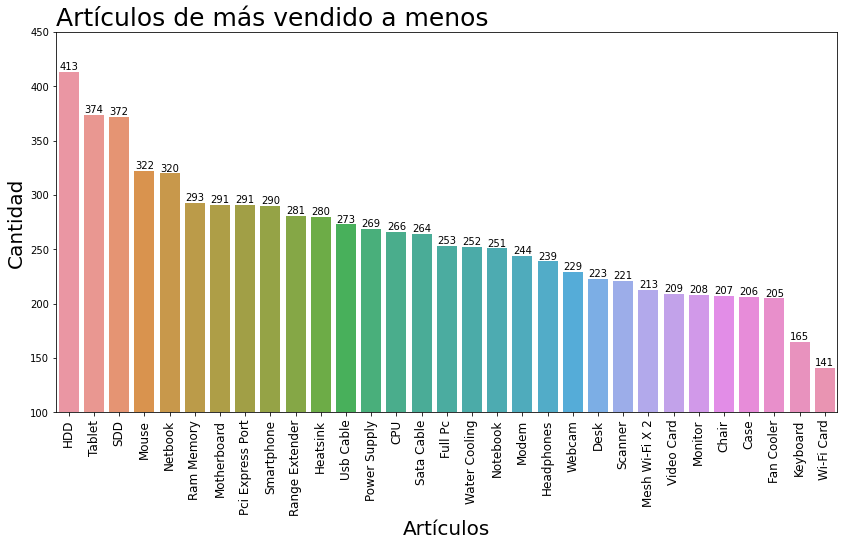

In [ ]:
# RESOLUCIÓN GRÁFICA
from matplotlib import rcParams
rcParams['figure.figsize'] = 14,7
plt.title('Artículos de más vendido a menos', fontsize=25, loc='left')
art = sns.barplot(x=df2.index,y=df2['quantity'],data=df2,order=df2.sort_values('quantity', ascending=False).index)
plt.xlabel('Artículos', fontsize = 20)
plt.ylabel('Cantidad', fontsize = 20)
plt.xticks(rotation=90, fontsize=12)
plt.ylim(100, 450)
art.bar_label(art.containers[0])

plt.savefig('P1.png', dpi=300)
plt.show()

<h3>2. ¿Qué artículo es el que más ingresos nos proporcionó?</h3>

In [ ]:
# RESOLUCIÓN ANALÍTICA
df3=(my_df.groupby('article_name').sum()).sort_values('total_amount', ascending=False).head(5)
print(df3['total_amount'])


article_name
Full Pc      $ 538,335.93
Notebook     $ 251,000.00
Smartphone   $ 152,250.00
Chair         $ 69,477.48
Tablet        $ 48,620.00
Name: total_amount, dtype: float64


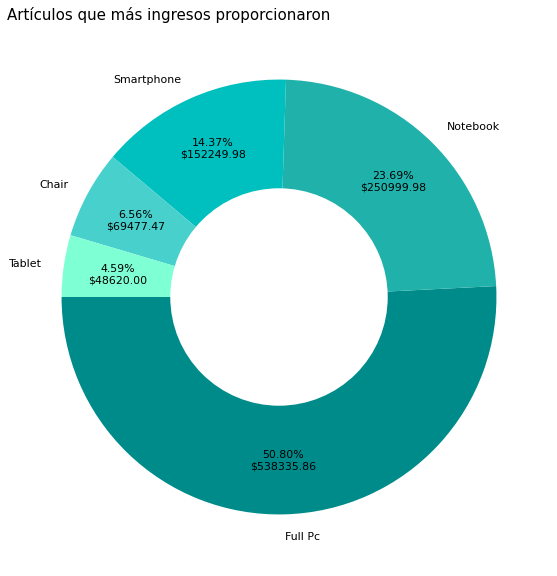

In [ ]:
# RESOLUCIÓN GRÁFICA 
def your_autopct_format(prct_value):
    return '{:.2f}%\n${:.2f}'.format(prct_value, 1059683.41*prct_value/100)

rcParams['figure.figsize'] = 10,10
#c = ['lightgreen', 'lightsteelblue', 'thistle','lightpink', 'khaki']
c = ['darkcyan','lightseagreen','c','mediumturquoise', 'aquamarine']
textprops = {"fontsize":11}

plt.title('Artículos que más ingresos proporcionaron', fontsize=15, loc='left')
plt.pie(x=df3['total_amount'], labels=df3.index, colors=c, startangle=180, autopct=your_autopct_format, pctdistance=0.75, textprops=textprops)

cc = plt.Circle((0,0),0.5,fc='white')
fig = plt.gcf()
fig.gca().add_artist(cc)

plt.savefig('P2.png', dpi=300)
plt.show()

<h3>3. ¿A qué vendedor debe otorgarse el bono por "Mejor vendedor del mes"?</h3>

In [ ]:
# RESOLUCIÓN ANALÍTICA
df4=(my_df.groupby('seller_name').sum()).sort_values('total_amount', ascending=False)
print('Respuesta:', df4.head(1))
print()
print(df4[['quantity']+['total_amount']])

Respuesta:                 week  quantity  total_amount
seller_name                                 
Janel O'Curran   174       703  $ 192,832.47

                   quantity  total_amount
seller_name                              
Janel O'Curran          703  $ 192,832.47
Brockie Patience        441  $ 142,709.88
Oliviero Charkham       555  $ 141,329.76
Vasily Danilyuk         521  $ 129,157.55
Daisie Slograve         554  $ 120,520.11
Aveline Swanwick        629  $ 118,874.33
Arnold Kilkenny         583   $ 94,552.04
Kati Innot              512   $ 83,704.62
Jase Doy                582   $ 80,628.31
Ewell Peres             496   $ 78,144.32
Onida Cosely            535   $ 77,373.37
Milly Christoffe        442   $ 61,733.69
Tobin Roselli           519   $ 56,984.42
Cornie Wynrehame        523   $ 52,253.57
Cirilo Grandham         470   $ 45,009.40


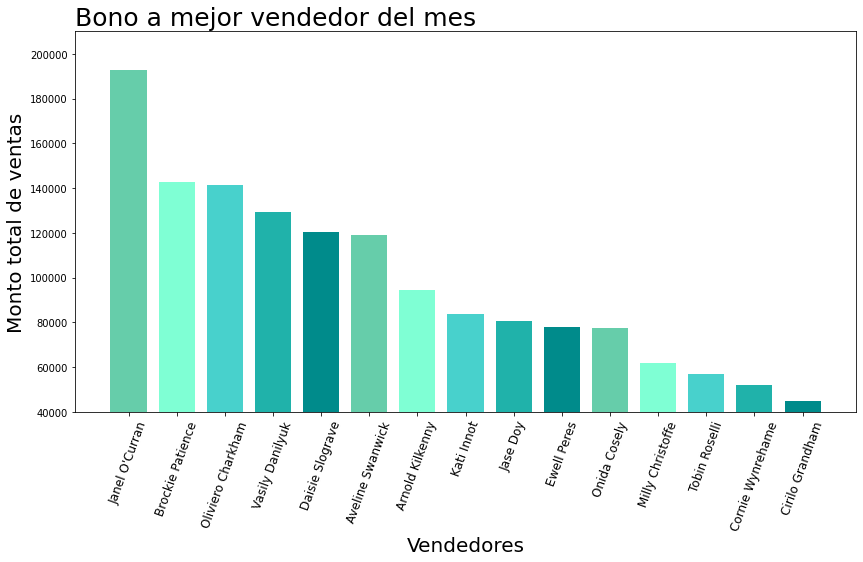

<Figure size 1008x504 with 0 Axes>

In [ ]:
# RESOLUCIÓN GRÁFICA

rcParams['figure.figsize'] = 14,7
x=df4.index
y=df4['total_amount']

plt.bar(x,y, width=0.75, color=['mediumaquamarine', 'aquamarine', 'mediumturquoise', 'lightseagreen', 'darkcyan', 'mediumaquamarine', 'aquamarine', 'mediumturquoise', 'lightseagreen', 'darkcyan', 'mediumaquamarine', 'aquamarine', 'mediumturquoise', 'lightseagreen', 'darkcyan'])
plt.xticks(rotation=70, fontsize=12)
plt.title('Bono a mejor vendedor del mes', fontsize=25, loc='left')
plt.xlabel('Vendedores', fontsize = 20)
plt.ylabel('Monto total de ventas', fontsize = 20)
plt.ylim(40000, 210000)
plt.show()

#rcParams['figure.figsize'] = 14,7
#x=df4.index
#y=df4['total_amount']

#barras = plt.bar(x,y, width=0.5, color=['mediumaquamarine', 'aquamarine', 'mediumturquoise', 'lightseagreen', 'darkcyan', 'mediumaquamarine', 'aquamarine', 'mediumturquoise', 'lightseagreen', 'darkcyan', 'mediumaquamarine', 'aquamarine', 'mediumturquoise', 'lightseagreen', 'darkcyan'])
#plt.xticks(rotation=70, fontsize=12)
#plt.title('Bono a mejor vendedor del mes', fontsize=25, loc='left')
#plt.xlabel('Vendedores', fontsize = 20)
#plt.ylabel('Monto total de ventas', fontsize = 20)
#plt.ylim(40000, 200000)
#def addlabels(x,y):
 #   for i in range(len(x)):
  #      plt.text(i,y[i],y[i], ha = 'center')
#addlabels(x, y,)

plt.savefig('P3.png', dpi=300)
#plt.show()



<h3>4. ¿Hay grandes variaciones en ventas a lo largo del mes?</h3>
<h4>Si es así, ¿en qué momento debería lanzar una campaña de promociones?</h4>


In [ ]:
# RESOLUCIÓN ANALÍTICA
df5=(my_df.groupby('week').sum()).sort_values('total_amount', ascending=False)
print(df5)

      quantity  total_amount
week                        
1         2449  $ 507,458.81
2         2444  $ 415,364.44
3         2114  $ 329,140.03
4         1058  $ 223,844.56


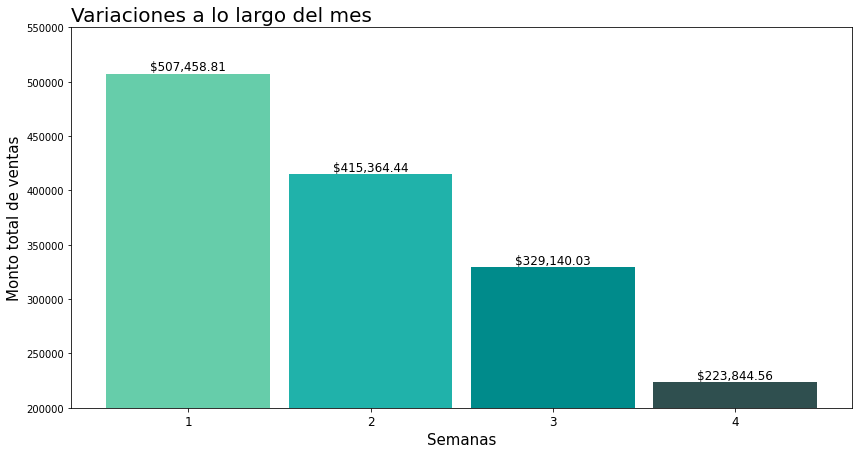

In [ ]:
# RESOLUCIÓN GRÁFICA
bars=plt.bar(df5.index,df5['total_amount'], width=0.9, color=['mediumaquamarine','lightseagreen','darkcyan','darkslategray'])
plt.bar_label(bars, labels=[f'${x:,.2f}' for x in bars.datavalues], fontsize=12, )
plt.title('Variaciones a lo largo del mes', fontsize=20, loc='left')
plt.ylim(200000, 550000)
labels = [1, 2, 3, 4]
plt.xticks(labels,fontsize=12)
plt.xlabel('Semanas', fontsize = 15)
plt.ylabel('Monto total de ventas', fontsize = 15)

plt.savefig('P4.png', dpi=300)
plt.show()

<h2>Tareas a realizar</h2>
<ul>
<li>Pensar 3 preguntas y responderlas con el método que consideres más apropiado. Al menos una de ellas debe contener la columna 'country_name' y al menos una de ellas debe buscar correlación entre dos variables categóricas.</li>
<li>Personalizar, estilar y dar contexto a las gráficas.</li>
<li>Generar un informe en el que se responda en forma coloquial a las preguntas, agregando conclusiones y consejos que puedan surgir de este trabajo. Se pueden agregar imágenes.</li>
<li>Publicar el trabajo y concretar la entrega en <a href="https://docs.google.com/forms/d/e/1FAIpQLSdiu_l6aO4tKBLiojZJp-RLF--deRAW0VM-0eqQ9tHJSD-j7A/viewform">https://docs.google.com/forms/d/e/1FAIpQLSdiu_l6aO4tKBLiojZJp-RLF--deRAW0VM-0eqQ9tHJSD-j7A/viewform</a>. <br>Deberás proporcionar link al notebook fuente y a la publicación. <br>Video/guía de cómo entregar el trabajo: <a href="https://youtu.be/FCQRhs4dxls">https://youtu.be/FCQRhs4dxls</a></li>
<li>Entregas:  4 de julio hasta 15 de julio, 2022 - 23:59 hs</li>
</ul>

<h3>5. ¿Cuáles son los 5 países con mayor cantidad de ventas?</h3>

In [ ]:
# RESOLUCIÓN ANALÍTICA
df6 = (my_df.groupby('country_name').sum()).sort_values('total_amount', ascending=False).head(5)
print(df6['total_amount'])

country_name
Brazil      $ 441,271.85
Argentina   $ 205,832.78
Colombia    $ 177,514.29
Peru        $ 161,421.12
Mexico      $ 138,619.99
Name: total_amount, dtype: float64


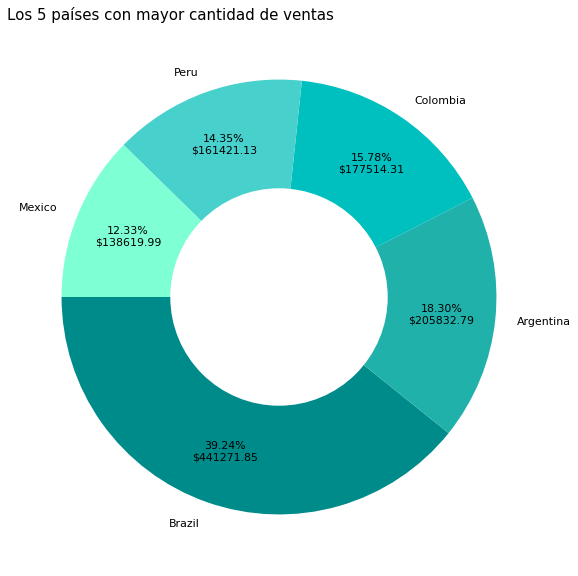

In [ ]:
# RESOLUCIÓN GRÁFICA 
def your_autopct_format(prct_value):
        return '{:.2f}%\n${:.2f}'.format(prct_value, 1124660.03*prct_value/100)

rcParams['figure.figsize'] = 10,10
c = ['darkcyan','lightseagreen','c','mediumturquoise', 'aquamarine']
textprops = {"fontsize":11}

plt.title('Los 5 países con mayor cantidad de ventas', fontsize=15, loc='left')
paises=plt.pie(x=df6['total_amount'], labels=df6.index,colors=c, startangle=180, autopct=your_autopct_format, pctdistance=0.75, textprops=textprops)

cc = plt.Circle((0,0),0.5,fc='white')
fig = plt.gcf()
fig.gca().add_artist(cc)

plt.savefig('P5.png', dpi=300)
plt.show()

<h3>6.¿Cuál es el artículo más vendido en cada país?</h3>

In [ ]:
# RESOLUCIÓN ANALÍTICA

df7 = my_df.groupby(['country_name','article_name'])['quantity'].sum().reset_index()
df7 = df7.sort_values(by=['quantity'],ascending=False).groupby(['country_name']).first()
print(df7)

#my_df_aux = my_df.copy()
#df7 = (my_df.groupby('country_name').sum())
#]and('article_name').sum()).sort_values('quantity', ascending=False)
#print(df7['quantity'])

#my_df_aux_agrupado_pais = my_df_aux.groupby(['country_name','article_name'])['quantity'].sum().reset_index()
#my_df_aux_agrupado_pais = my_df_aux_agrupado_pais.sort_values(by=['quantity'],ascending=False).groupby(['country_name']).first()
#my_df_aux_agrupado_pais



                  article_name  quantity
country_name                            
Argentina                  CPU       104
Bolivia       Pci Express Port        34
Brazil                  Tablet       156
Chile                    Mouse        27
Colombia                   SDD        74
Costa Rica        Power Supply        32
Ecuador           Power Supply        24
El Salvador         Smartphone        22
Guatemala             Heatsink        25
Honduras        Mesh Wi-Fi X 2        28
Mexico                     HDD        63
Paraguay            Headphones        24
Peru                     Mouse       125
Puerto Rico                CPU         9
Uruguay            Motherboard        15
Venezuela           Smartphone        32


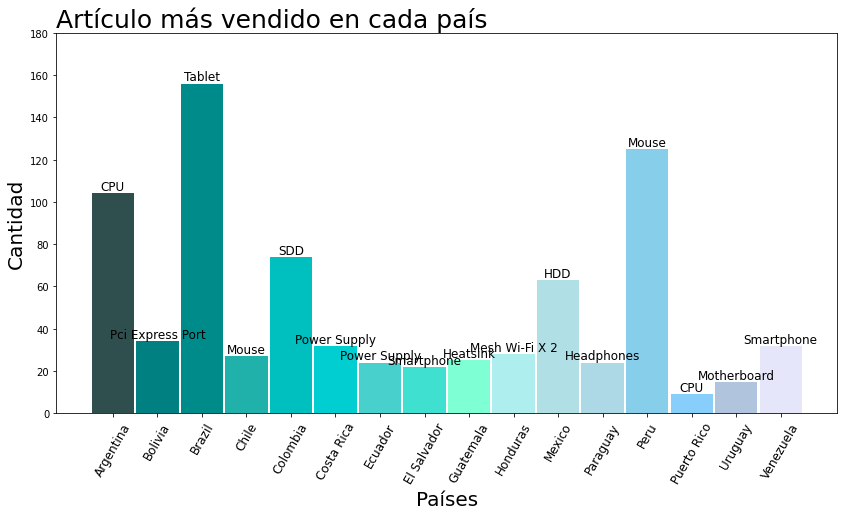

In [ ]:
# RESOLUCIÓN GRÁFICA
bars = plt.bar(df7.index,df7['quantity'], width=0.95, color=['darkslategray', 'teal', 'darkcyan', 'lightseagreen', 'c', 'darkturquoise','mediumturquoise','turquoise', 'aquamarine', 'paleturquoise', 'powderblue', 'lightblue', 'skyblue', 'lightskyblue', 'lightsteelblue','lavender'])
plt.bar_label(bars, labels=df7['article_name'], fontsize=12, )

plt.title('Artículo más vendido en cada país', fontsize=25, loc='left')
plt.xlabel('Países', fontsize = 20)
plt.ylabel('Cantidad', fontsize = 20)
plt.xticks(rotation=60, fontsize=12)
plt.ylim(0,180)

plt.savefig('P6.png', dpi=300)
plt.show()

<h3>7. ¿Cuál es el artículo que menos ingresos nos proporcionó?</h3>

In [ ]:
# RESOLUCIÓN ANALÍTICA
df8=(my_df.groupby('article_name').sum()).sort_values('total_amount', ascending=True).head(10)
df9=((my_df.groupby('article_name').sum()).sort_values('total_amount', ascending=True).head(10)).sum()

print(df8['total_amount'])
print()
print('Suma de los montos totales de los 10 que menos ingresos dieron: $',df9['total_amount'])

article_name
Sata Cable           $ 564.96
Usb Cable            $ 805.35
Fan Cooler           $ 871.25
Heatsink           $ 2,800.00
Pci Express Port   $ 2,944.92
Keyboard           $ 3,729.00
Webcam             $ 4,596.03
Headphones         $ 5,568.70
Range Extender     $ 5,746.45
Mesh Wi-Fi X 2     $ 6,922.50
Name: total_amount, dtype: float64

Suma de los montos totales de los 10 que menos ingresos dieron: $ 34549.16


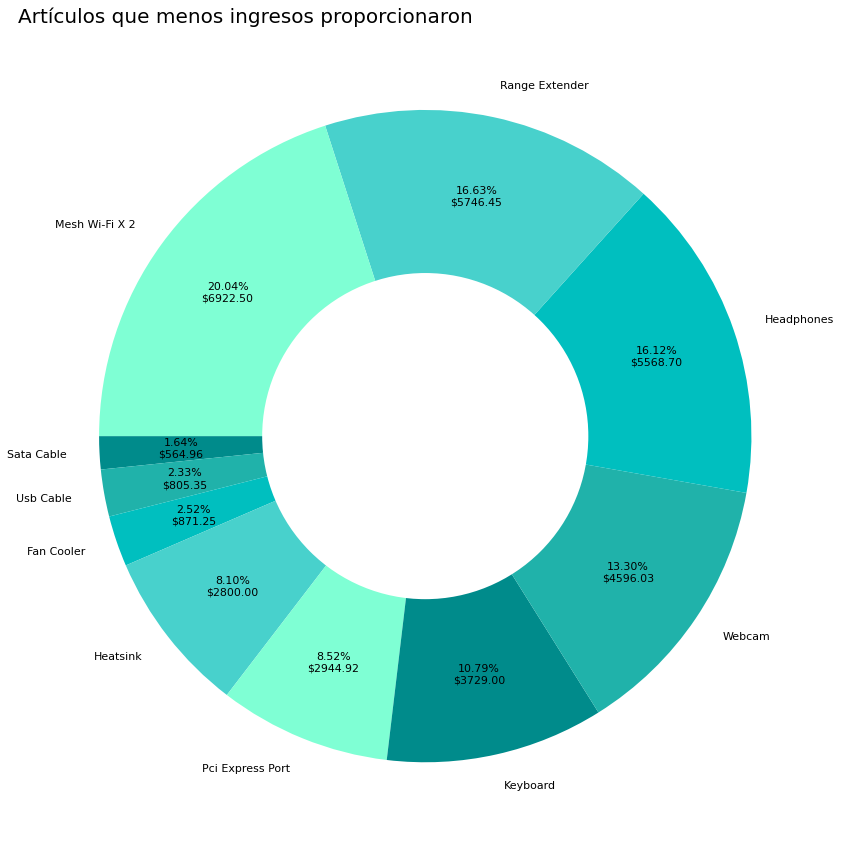

In [ ]:
# RESOLUCIÓN GRÁFICA
def your_autopct_format(prct_value):
    return '{:.2f}%\n${:.2f}'.format(prct_value, 34549.16*prct_value/100)

rcParams['figure.figsize'] = 15,15
c = ['darkcyan','lightseagreen','c','mediumturquoise', 'aquamarine']
textprops = {"fontsize":11}

plt.title('Artículos que menos ingresos proporcionaron', fontsize=20, loc='left')
plt.pie(x=df8['total_amount'], colors=c,labels=df8.index, startangle=180, autopct=your_autopct_format, pctdistance=0.75, textprops=textprops)

cc = plt.Circle((0,0),0.5,fc='white')
fig = plt.gcf()
fig.gca().add_artist(cc)

plt.savefig('P7.png', dpi=300)
plt.show()

<h2>Conclusiones y Recomendaciones</h2>

<p>A partir del análisis realizado, se identifican hallazgos relevantes en términos de desempeño por país, productos y fuerza de ventas, que permiten definir oportunidades concretas de mejora y optimización comercial.</p>




<h3>Desempeño por país</h3>

<p><b>Brasil</b> se posiciona como el mercado líder en volumen de ventas, duplicando al segundo país en el ranking. Asimismo, sus ingresos superan en aproximadamente $15.000 al total generado durante la segunda semana del período analizado.</p>

<p>Esto implica que cerca de un cuarto de las ventas mensuales se concentran en un solo país, evidenciando una fuerte dependencia de este mercado.</p>

<p>Se recomienda analizar en profundidad las estrategias comerciales implementadas en Brasil, con el objetivo de replicar prácticas exitosas en mercados secundarios como <b>Argentina, Colombia, Perú y México</b>.</p>





<h3>Análisis de productos</h3>

<p>Se observa que la <b>tablet</b> es el producto más demandado en Brasil, posicionándose además como el segundo artículo más vendido a nivel general y el quinto en generación de ingresos.</p>

<p>Por otro lado, la <b>full pc</b> es el producto que mayor ingreso genera, a pesar de no destacarse en volumen de ventas, lo que sugiere un mayor margen unitario.</p>

<p>Se recomienda evaluar la estructura de costos y márgenes por producto para identificar oportunidades de optimización y priorización en la estrategia comercial.</p>

<p>Un caso destacado es la <b>notebook</b>, que combina buen volumen de ventas con alta generación de ingresos, constituyendo un modelo de producto equilibrado a analizar y potenciar.</p>








<h3>Consumo por país</h3>

<p>El <b>HDD</b> se posiciona como el producto más vendido (413 unidades), con una participación relevante de <b>México</b> (15% del total).</p>

<p>Se recomienda profundizar el análisis del comportamiento del consumidor mexicano para identificar drivers de demanda replicables en otros mercados.</p>




<h3>Productos de bajo rendimiento</h3>

<p>Se detecta que en 4 de los 16 países analizados, el producto más vendido pertenece al grupo de los que menos ingresos generan:</p>

<p>
<b>Bolivia</b> – Pci Express Port<br>
<b>Guatemala</b> – Heatsink<br>
<b>Honduras</b> – Mesh Wi Fi X 2<br>
<b>Paraguay</b> – Headphones
</p>

<p>Se recomienda implementar estrategias comerciales orientadas a incentivar la venta de productos de mayor margen, rediseñar promociones o bundles y revisar la relevancia del portfolio actual en dichos mercados.</p>

<p>Adicionalmente, se observa que los ingresos combinados de los 10 productos de menor rendimiento son inferiores a los generados por un solo producto (<b>tablet</b>), lo que evidencia una ineficiencia en la asignación de recursos de stock.</p>

<p>Se sugiere evaluar la continuidad de estos productos o su inclusión en estrategias de venta combinada (bundling).</p>






<h3>Variación temporal de ventas</h3>

<p>El análisis temporal evidencia variaciones significativas en el comportamiento de las ventas a lo largo del mes, con una marcada concentración en el inicio del período.</p>

<p>En particular, los ingresos registrados durante la primera semana duplican a los de la cuarta semana, lo que refleja una disminución progresiva en la demanda a medida que transcurre el mes.</p>

<p>Este comportamiento sugiere la presencia de patrones de consumo específicos, posiblemente asociados a factores como disponibilidad de liquidez al inicio del mes, ciclos de pago o mayor predisposición a la compra en períodos iniciales.</p>

<p>Asimismo, la caída sostenida en las semanas posteriores podría indicar una falta de estímulos comerciales suficientes para sostener el nivel de ventas, o bien una saturación temprana de la demanda.</p>

<p>Desde una perspectiva estratégica, este patrón representa una oportunidad para optimizar la distribución temporal de ingresos y mejorar la estabilidad del flujo de ventas.</p>

<p>En este contexto, se recomienda implementar estrategias comerciales diferenciadas, tales como promociones escalonadas a lo largo del mes, campañas específicas en períodos de menor actividad o incentivos dirigidos a reactivar la demanda en las últimas semanas.</p>

<p>Adicionalmente, considerando la alta concentración de ventas al inicio del mes, también podría evaluarse una estrategia orientada a maximizar este pico mediante acciones comerciales más agresivas, como descuentos, campañas de alto impacto o lanzamientos estratégicos en dicho período.</p>

<p>Finalmente, se sugiere profundizar el análisis incorporando mayor nivel de detalle temporal (por día o tipo de producto), con el objetivo de identificar patrones más precisos que permitan una toma de decisiones aún más eficiente.</p>








<h3>Desempeño de vendedores</h3>

<p>El análisis del desempeño comercial permite identificar diferencias significativas en los resultados obtenidos por el equipo de ventas.</p>

<p>En este contexto, <b>Janel O’Curran</b> se posiciona como la vendedora con mejor rendimiento del período, alcanzando un total de ingresos de $192.833. Este nivel de desempeño no solo la ubica como líder del ranking, sino que además evidencia una alta efectividad en la gestión comercial, justificando plenamente la asignación del bono por “Mejor vendedor del mes”.</p>

<p>En contraste, se observa una brecha considerable respecto a los vendedores con menor rendimiento, lo que pone de manifiesto una dispersión significativa en los resultados individuales del equipo.</p>

<p>Esta variabilidad sugiere la existencia de diferencias en habilidades comerciales, gestión de clientes o aprovechamiento de oportunidades de venta, lo cual puede estar impactando en la eficiencia global del equipo.</p>

<p>Desde una perspectiva estratégica, resulta clave reducir esta brecha con el objetivo de elevar el rendimiento promedio y lograr una mayor consistencia en los resultados.</p>

<p>En este sentido, se recomienda implementar programas de capacitación comercial, instancias de seguimiento individual y estrategias de mentoring, tomando como referencia las buenas prácticas de los vendedores con mejor desempeño.</p>

<p>Adicionalmente, podría evaluarse la implementación de incentivos alineados a objetivos específicos, con el fin de motivar al equipo y potenciar el desempeño general.</p>



<h2>Conclusión general</h2>

<p>El presente análisis permitió integrar múltiples fuentes de datos para obtener una visión integral del desempeño comercial, identificando patrones relevantes en términos de mercados, productos, temporalidad de ventas y rendimiento del equipo comercial.</p>

<p>Se destaca una fuerte concentración de ventas en determinados países, particularmente en <b>Brasil</b>, así como una dependencia significativa de ciertos productos en la generación de ingresos, lo que evidencia oportunidades de diversificación y optimización del portfolio.</p>

<p>Asimismo, el análisis temporal permitió identificar una marcada estacionalidad dentro del mes, con una mayor concentración de ventas en el período inicial, lo que abre la posibilidad de implementar estrategias orientadas a equilibrar el flujo de ingresos.</p>

<p>Por otro lado, el estudio del desempeño de vendedores revela la existencia de brechas importantes dentro del equipo comercial, lo que sugiere la necesidad de fortalecer capacidades y estandarizar buenas prácticas.</p>

<p>En conjunto, estos hallazgos permiten definir líneas de acción concretas orientadas a mejorar la eficiencia comercial, optimizar la toma de decisiones y maximizar los resultados del negocio.</p>

<p>Finalmente, se recomienda continuar profundizando el análisis incorporando nuevas variables y períodos de tiempo más extensos, con el objetivo de validar tendencias, detectar oportunidades adicionales y consolidar una estrategia basada en datos.</p>
